<a href="https://colab.research.google.com/github/kra-dev007/Data-Analytics-using-Python---Projects/blob/main/E_Commerce_Sales_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: make plots look a little cleaner
plt.style.use("ggplot")

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("ecommerce_sales_final.csv")
print(df)

Saving ecommerce_sales_final.csv to ecommerce_sales_final.csv
     Order_ID  Order_Date Customer_ID       Product     Category  Quantity  \
0    ORD10276  2025-01-12    CUST1093           NaN         Home       5.0   
1    ORD10094         NaN    CUST1135           NaN  Accessories       2.0   
2    ORD10007  2025-05-07    CUST1148           NaN      Fashion       3.0   
3    ORD10168  2025-05-02    CUST1037           NaN  Electronics       5.0   
4    ORD10091  2025-05-05    CUST1079           NaN         Home       2.0   
..        ...         ...         ...           ...          ...       ...   
515  ORD10072         NaN    CUST1098   Smart Watch  Electronics       6.0   
516  ORD10107         NaN    CUST1129    Table Lamp         Home       3.0   
517  ORD10271         NaN    CUST1070      Backpack      Fashion       4.0   
518  ORD10436         NaN    CUST1101     USB Cable  Electronics       6.0   
519  ORD10103         NaN    CUST1075  Office Chair    Furniture       4.0   

 

In [ ]:
df.head(100)

,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Discount_%,Sales,City,Payment_Mode,Returned,Revenue,Estimated_Cost,Profit,Month,Total_Revenue
0,ORD10276,2025-01-12,CUST1093,NaN,Home,5.0,885.0,0.0,4425.0,Bangalore,UPI,Yes,4425.0,2655.00,1770.00,2025-01,4425.0
1,ORD10094,NaN,CUST1135,NaN,Accessories,2.0,1342.0,NaN,2684.0,Hyderabad,UPI,No,2684.0,1744.60,939.40,NaT,2684.0
2,ORD10007,2025-05-07,CUST1148,NaN,Fashion,3.0,1677.0,NaN,5031.0,Bangalore,UPI,Yes,5031.0,3119.22,1911.78,2025-05,5031.0
3,ORD10168,2025-05-02,CUST1037,NaN,Electronics,5.0,321.0,NaN,1605.0,Chennai,UPI,NaN,1605.0,1155.60,449.40,2025-05,1605.0
4,ORD10091,2025-05-05,CUST1079,NaN,Home,2.0,596.0,15.0,1013.2,Mumbai,Net Banking,NaN,1013.2,715.20,298.00,2025-05,1013.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD10347,2025-04-02,CUST1077,Table Lamp,Home,6.0,900.0,15.0,4590.0,Chennai,UPI,Yes,4590.0,3240.00,1350.00,2025-04,4590.0
96,ORD10132,NaN,CUST1074,Gaming Keyboard,Electronics,3.0,2421.0,NaN,7263.0,Coimbatore,UPI,No,7263.0,5229.36,2033.64,NaT,7263.0
97,ORD10434,2025-07-09,CUST1082,USB Cable,Electronics,6.0,382.0,15.0,1948.2,Coimbatore,Wallet,NaN,1948.2,1650.24,297.96,2025-07,1948.2
98,ORD10457,NaN,CUST1004,Backpack,Fashion,3.0,1652.0,10.0,4460.4,Delhi,UPI,No,4460.4,3072.72,1387.68,NaT,4460.4


In [ ]:
# Dataset Overview


print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (520, 17)

Columns:
['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Discount_%', 'Sales', 'City', 'Payment_Mode', 'Returned', 'Revenue', 'Estimated_Cost', 'Profit', 'Month', 'Total_Revenue']

First 5 rows:


,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Discount_%,Sales,City,Payment_Mode,Returned,Revenue,Estimated_Cost,Profit,Month,Total_Revenue
0,ORD10276,2025-01-12,CUST1093,NaN,Home,5.0,885.0,0.0,4425.0,Bangalore,UPI,Yes,4425.0,2655.00,1770.00,2025-01,4425.0
1,ORD10094,NaN,CUST1135,NaN,Accessories,2.0,1342.0,NaN,2684.0,Hyderabad,UPI,No,2684.0,1744.60,939.40,NaT,2684.0
2,ORD10007,2025-05-07,CUST1148,NaN,Fashion,3.0,1677.0,NaN,5031.0,Bangalore,UPI,Yes,5031.0,3119.22,1911.78,2025-05,5031.0
3,ORD10168,2025-05-02,CUST1037,NaN,Electronics,5.0,321.0,NaN,1605.0,Chennai,UPI,NaN,1605.0,1155.60,449.40,2025-05,1605.0
4,ORD10091,2025-05-05,CUST1079,NaN,Home,2.0,596.0,15.0,1013.2,Mumbai,Net Banking,NaN,1013.2,715.20,298.00,2025-05,1013.2



Missing values:
Order_ID            0
Order_Date        342
Customer_ID         0
Product            12
Category            0
Quantity           10
Unit_Price         10
Discount_%         82
Sales               8
City                8
Payment_Mode        0
Returned           98
Revenue             8
Estimated_Cost     20
Profit             28
Month               0
Total_Revenue       8
dtype: int64

Duplicate rows: 16


In [ ]:
clean_df = df.copy()

In [ ]:

# Remove Duplicate Rows


print("Before removing duplicates:", clean_df.shape)
clean_df = clean_df.drop_duplicates()
print("After removing duplicates:", clean_df.shape)

Before removing duplicates: (520, 17)
After removing duplicates: (504, 17)


In [ ]:
# Clean Product Names


clean_df["Product"] = clean_df["Product"].astype(str).str.strip().str.lower().str.title()
clean_df["Product"] = clean_df["Product"].replace("Nan", np.nan)

clean_df["Product"].head()

,Product
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [ ]:
# Convert Order_Date into datetime


clean_df["Order_Date"] = pd.to_datetime(clean_df["Order_Date"], errors="coerce", dayfirst=True)
print("Invalid dates:", clean_df["Order_Date"].isnull().sum())

Invalid dates: 331


In [ ]:
# Convert numeric columns


numeric_cols = [
    "Quantity", "Unit_Price", "Discount_%", "Sales",
    "Revenue", "Estimated_Cost", "Profit", "Total_Revenue"
]

for col in numeric_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

clean_df[numeric_cols].head()

,Quantity,Unit_Price,Discount_%,Sales,Revenue,Estimated_Cost,Profit,Total_Revenue
0,5.0,885.0,0.0,4425.0,4425.0,2655.00,1770.00,4425.0
1,2.0,1342.0,NaN,2684.0,2684.0,1744.60,939.40,2684.0
2,3.0,1677.0,NaN,5031.0,5031.0,3119.22,1911.78,5031.0
3,5.0,321.0,NaN,1605.0,1605.0,1155.60,449.40,1605.0
4,2.0,596.0,15.0,1013.2,1013.2,715.20,298.00,1013.2


In [ ]:
# Fill Missing Values


# Fill numeric columns with median
for col in numeric_cols:
    clean_df[col].fillna(clean_df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_cols = ["Product", "Category", "City", "Payment_Mode", "Returned"]

for col in categorical_cols:
    clean_df[col].fillna(clean_df[col].mode()[0], inplace=True)

print("Missing values after cleaning:\n")
print(clean_df.isnull().sum())

Missing values after cleaning:

Order_ID            0
Order_Date        331
Customer_ID         0
Product             0
Category            0
Quantity            0
Unit_Price          0
Discount_%          0
Sales               0
City                0
Payment_Mode        0
Returned            0
Revenue             0
Estimated_Cost      0
Profit              0
Month               0
Total_Revenue       0
dtype: int64


/tmp/ipykernel_1781/3664411745.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df[col].fillna(clean_df[col].median(), inplace=True)
/tmp/ipykernel_1781/3664411745.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [ ]:
# Create / Fix Month Column


clean_df["Month"] = clean_df["Order_Date"].dt.to_period("M").astype(str)

clean_df[["Order_Date", "Month"]].head()

,Order_Date,Month
0,2025-12-01,2025-12
1,NaT,NaT
2,2025-07-05,2025-07
3,2025-02-05,2025-02
4,2025-05-05,2025-05


In [ ]:
# Recalculate Total Revenue and Profit


# Total Revenue = Sales / Revenue
clean_df["Total_Revenue"] = clean_df["Revenue"]

# Profit = Revenue - Estimated Cost
clean_df["Profit"] = clean_df["Total_Revenue"] - clean_df["Estimated_Cost"]

clean_df[["Total_Revenue", "Estimated_Cost", "Profit"]].head()

,Total_Revenue,Estimated_Cost,Profit
0,4425.0,2655.00,1770.00
1,2684.0,1744.60,939.40
2,5031.0,3119.22,1911.78
3,1605.0,1155.60,449.40
4,1013.2,715.20,298.00


In [ ]:
print("Cleaned dataset shape:", clean_df.shape)
display(clean_df.head())

print("\nFinal Missing Values:")
print(clean_df.isnull().sum())

Cleaned dataset shape: (504, 17)


,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Discount_%,Sales,City,Payment_Mode,Returned,Revenue,Estimated_Cost,Profit,Month,Total_Revenue
0,ORD10276,2025-12-01,CUST1093,Laptop Stand,Home,5.0,885.0,0.0,4425.0,Bangalore,UPI,Yes,4425.0,2655.00,1770.00,2025-12,4425.0
1,ORD10094,NaT,CUST1135,Laptop Stand,Accessories,2.0,1342.0,10.0,2684.0,Hyderabad,UPI,No,2684.0,1744.60,939.40,NaT,2684.0
2,ORD10007,2025-07-05,CUST1148,Laptop Stand,Fashion,3.0,1677.0,10.0,5031.0,Bangalore,UPI,Yes,5031.0,3119.22,1911.78,2025-07,5031.0
3,ORD10168,2025-02-05,CUST1037,Laptop Stand,Electronics,5.0,321.0,10.0,1605.0,Chennai,UPI,No,1605.0,1155.60,449.40,2025-02,1605.0
4,ORD10091,2025-05-05,CUST1079,Laptop Stand,Home,2.0,596.0,15.0,1013.2,Mumbai,Net Banking,No,1013.2,715.20,298.00,2025-05,1013.2



Final Missing Values:
Order_ID            0
Order_Date        331
Customer_ID         0
Product             0
Category            0
Quantity            0
Unit_Price          0
Discount_%          0
Sales               0
City                0
Payment_Mode        0
Returned            0
Revenue             0
Estimated_Cost      0
Profit              0
Month               0
Total_Revenue       0
dtype: int64


In [ ]:
top_products_revenue = clean_df.groupby("Product")["Total_Revenue"].sum().sort_values(ascending=False)

print("Top Products by Total Revenue:\n")
print(top_products_revenue)

Top Products by Total Revenue:

Product
Office Chair         934728.200
Smart Watch          633532.600
Gaming Keyboard      302288.450
Laptop Stand         266871.625
Backpack             249623.050
Bluetooth Speaker    202265.375
Table Lamp           137604.550
Wireless Mouse       115719.200
Water Bottle          63587.900
Coffee Mug            48159.550
Usb Cable             44689.700
Notebook              21945.050
Name: Total_Revenue, dtype: float64


In [ ]:
# Top Products by Profit


top_products_profit = clean_df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

print("Top Products by Profit:\n")
print(top_products_profit)

Top Products by Profit:

Product
Office Chair         192498.530
Smart Watch          181003.240
Backpack              84656.510
Laptop Stand          77186.925
Gaming Keyboard       69187.730
Bluetooth Speaker     48011.135
Table Lamp            46499.230
Wireless Mouse        26851.040
Water Bottle          18536.660
Coffee Mug            15367.030
Usb Cable             12322.820
Notebook               6436.480
Name: Profit, dtype: float64


In [ ]:
# Top Selling Products by Quantity Sold


top_selling_products = clean_df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

print("Top Selling Products by Quantity:\n")
print(top_selling_products.head(10))

Top Selling Products by Quantity:

Product
Laptop Stand      216.0
Smart Watch       169.0
Backpack          167.0
Table Lamp        161.0
Office Chair      155.0
Wireless Mouse    151.0
Coffee Mug        142.0
Notebook          140.0
Usb Cable         140.0
Water Bottle      137.0
Name: Quantity, dtype: float64


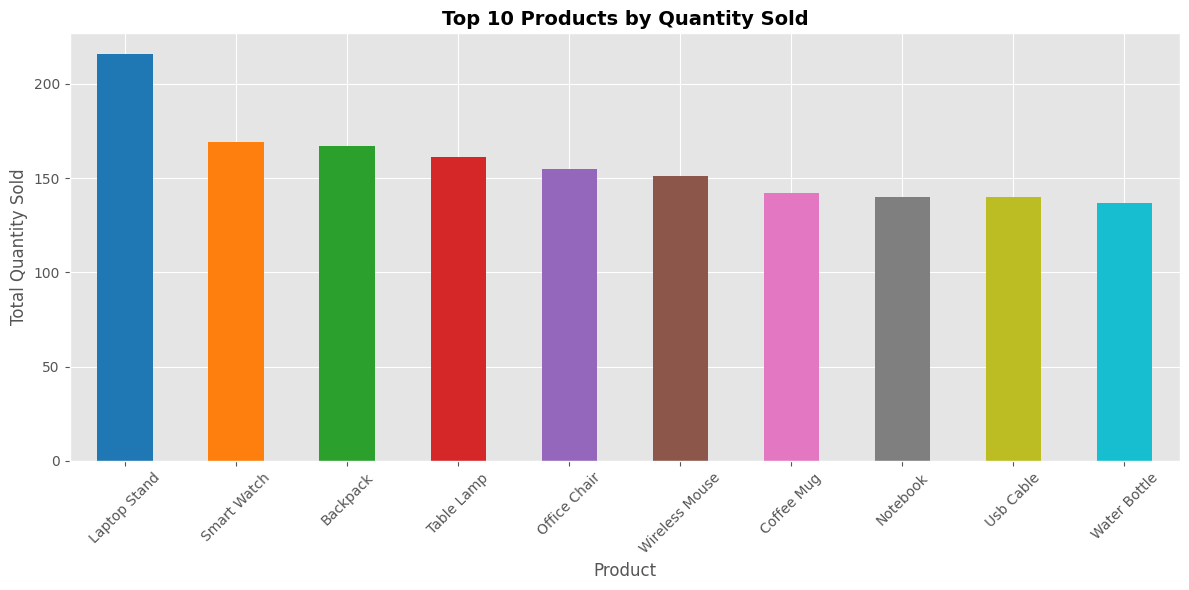

In [ ]:
top_selling_products = clean_df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)

# Define colors list - It appears this was defined later in another cell.
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
          "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

plt.figure(figsize=(12,6))
top_selling_products.plot(kind="bar", color=colors) # Reusing the 'colors' list from previous plots

plt.title("Top 10 Products by Quantity Sold", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_revenue = clean_df.groupby("Month")["Total_Revenue"].sum().sort_index()

print("Monthly Total Revenue:\n")
print(monthly_revenue)

Monthly Total Revenue:

Month
2025-01      27969.600
2025-02      95912.300
2025-03      43778.275
2025-04      65766.250
2025-05      95949.625
2025-06      82992.600
2025-07      85689.875
2025-08     125898.350
2025-09      42676.600
2025-10     121358.550
2025-11     120858.950
2025-12      71876.300
NaT        2040287.975
Name: Total_Revenue, dtype: float64


In [ ]:
monthly_profit = clean_df.groupby("Month")["Profit"].sum().sort_index()

print("Monthly Profit:\n")
print(monthly_profit)

Monthly Profit:

Month
2025-01      8277.360
2025-02     22559.960
2025-03      9696.885
2025-04     16453.760
2025-05     22503.715
2025-06     21153.520
2025-07     37420.445
2025-08     25220.310
2025-09     13272.800
2025-10     28898.270
2025-11     27945.070
2025-12     14240.500
NaT        530914.735
Name: Profit, dtype: float64


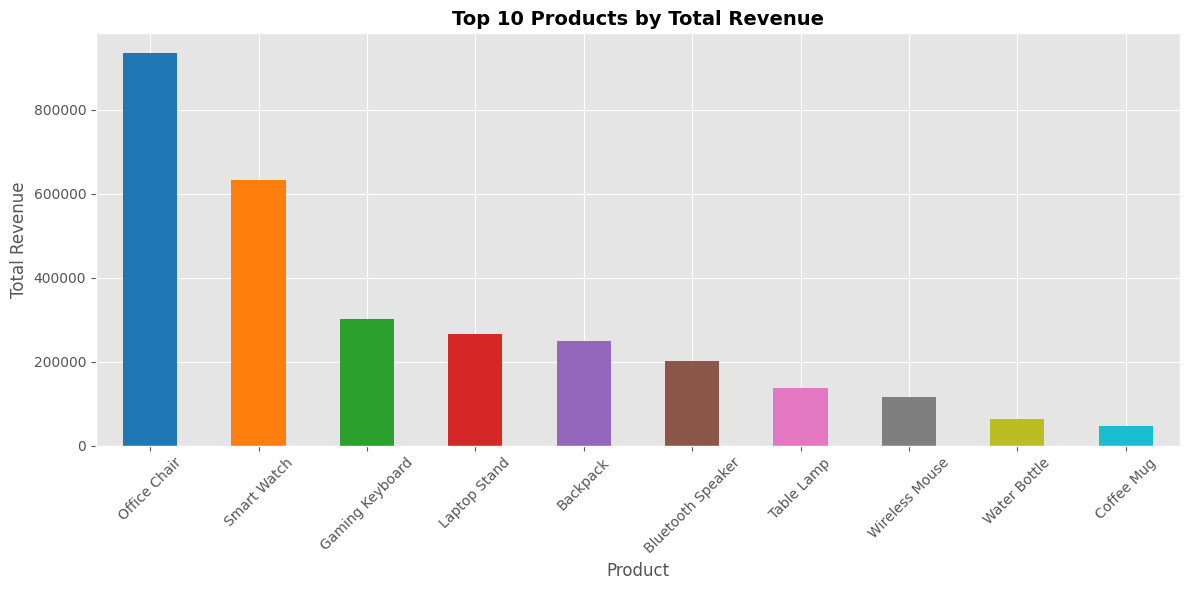

In [ ]:
# Bar Chart - Top 10 Products by Total Revenue

top_10_products = clean_df.groupby("Product")["Total_Revenue"].sum().sort_values(ascending=False).head(10)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
          "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

plt.figure(figsize=(12,6))
top_10_products.plot(kind="bar", color=colors)

plt.title("Top 10 Products by Total Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

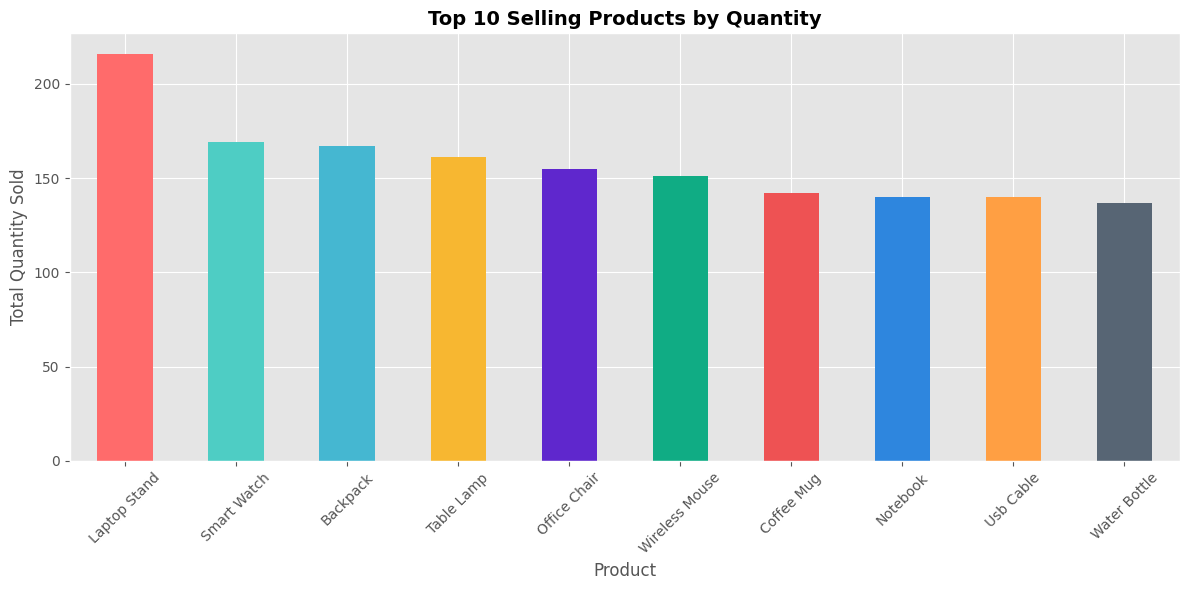

In [ ]:
# Bar Chart - Top 10 Selling Products by Quantity


top_10_selling = clean_df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)

colors = ["#ff6b6b", "#4ecdc4", "#45b7d1", "#f7b731", "#5f27cd",
          "#10ac84", "#ee5253", "#2e86de", "#ff9f43", "#576574"]

plt.figure(figsize=(12,6))
top_10_selling.plot(kind="bar", color=colors)

plt.title("Top 10 Selling Products by Quantity", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

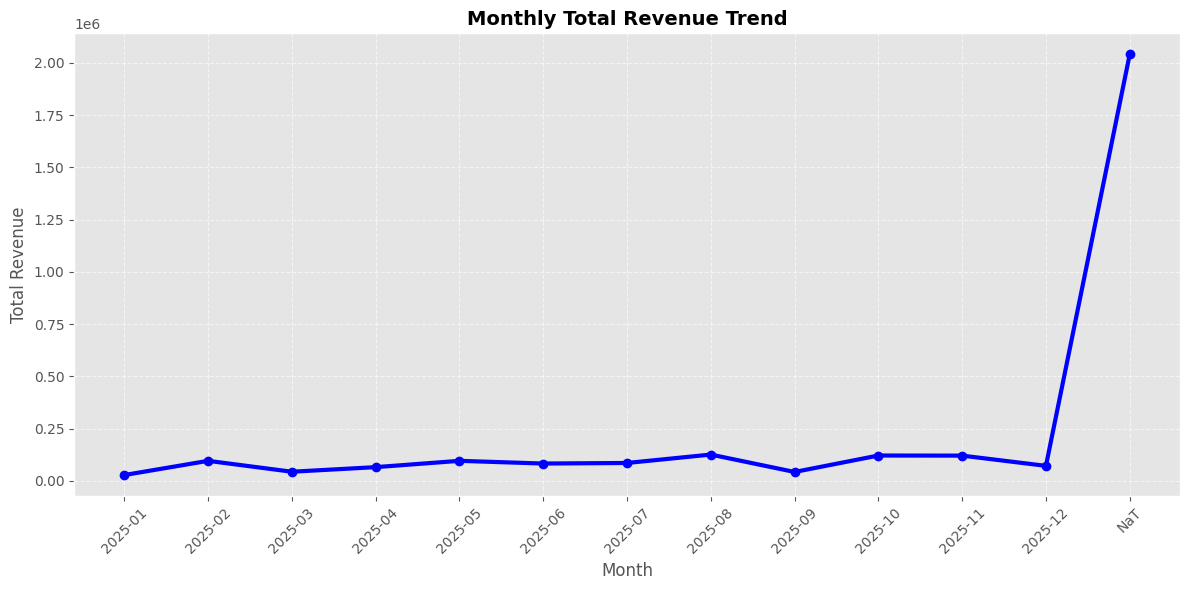

In [ ]:
# Line Chart - Monthly Total Revenue Trend


monthly_revenue = clean_df.groupby("Month")["Total_Revenue"].sum().sort_index()

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", linewidth=3, color="blue")
plt.title("Monthly Total Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

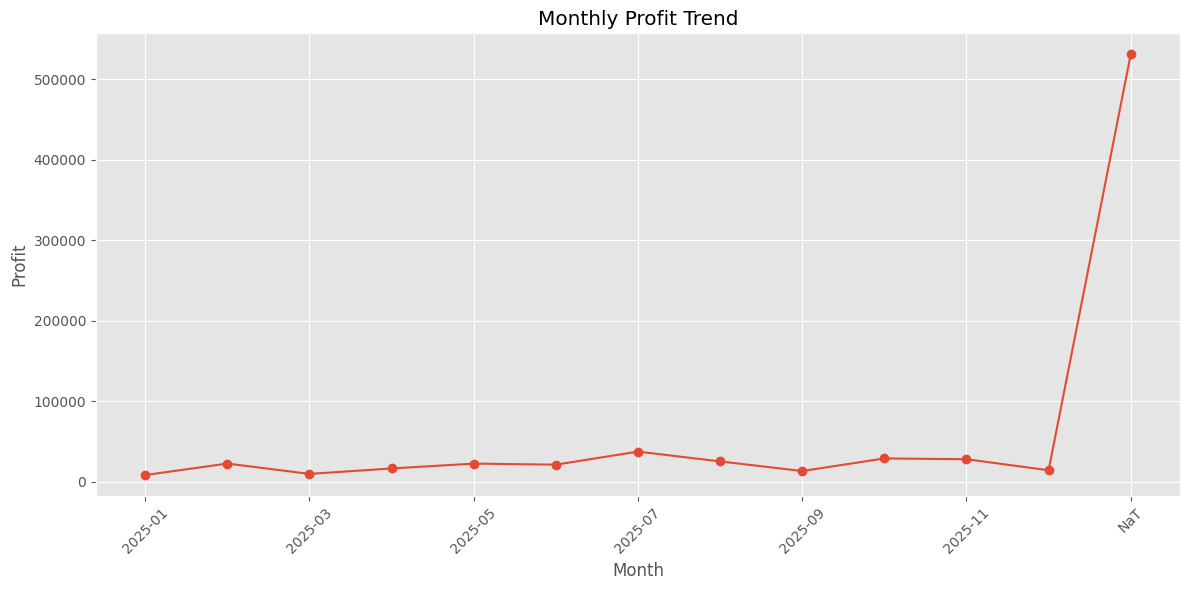

In [ ]:
# Line Chart - Monthly Profit Trend

monthly_profit = clean_df.groupby("Month")["Profit"].sum().sort_index()

plt.figure(figsize=(12,6))
monthly_profit.plot(kind="line", marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("=== E-Commerce Sales Performance Analysis ===\n")

print("Total Orders:", len(clean_df))
print("Total Revenue:", round(clean_df["Total_Revenue"].sum(), 2))
print("Total Profit:", round(clean_df["Profit"].sum(), 2))

top_product_revenue = clean_df.groupby("Product")["Total_Revenue"].sum().sort_values(ascending=False).head(1)
top_product_profit = clean_df.groupby("Product")["Profit"].sum().sort_values(ascending=False).head(1)
best_month = clean_df.groupby("Month")["Total_Revenue"].sum().sort_values(ascending=False).head(1)

print("\nTop Product by Revenue:")
print(top_product_revenue)

print("\nTop Product by Profit:")
print(top_product_profit)

print("\nBest Month by Revenue:")
print(best_month)

=== E-Commerce Sales Performance Analysis ===

Total Orders: 504
Total Revenue: 3021015.25
Total Profit: 778557.33

Top Product by Revenue:
Product
Office Chair    934728.2
Name: Total_Revenue, dtype: float64

Top Product by Profit:
Product
Office Chair    192498.53
Name: Profit, dtype: float64

Best Month by Revenue:
Month
NaT    2040287.975
Name: Total_Revenue, dtype: float64


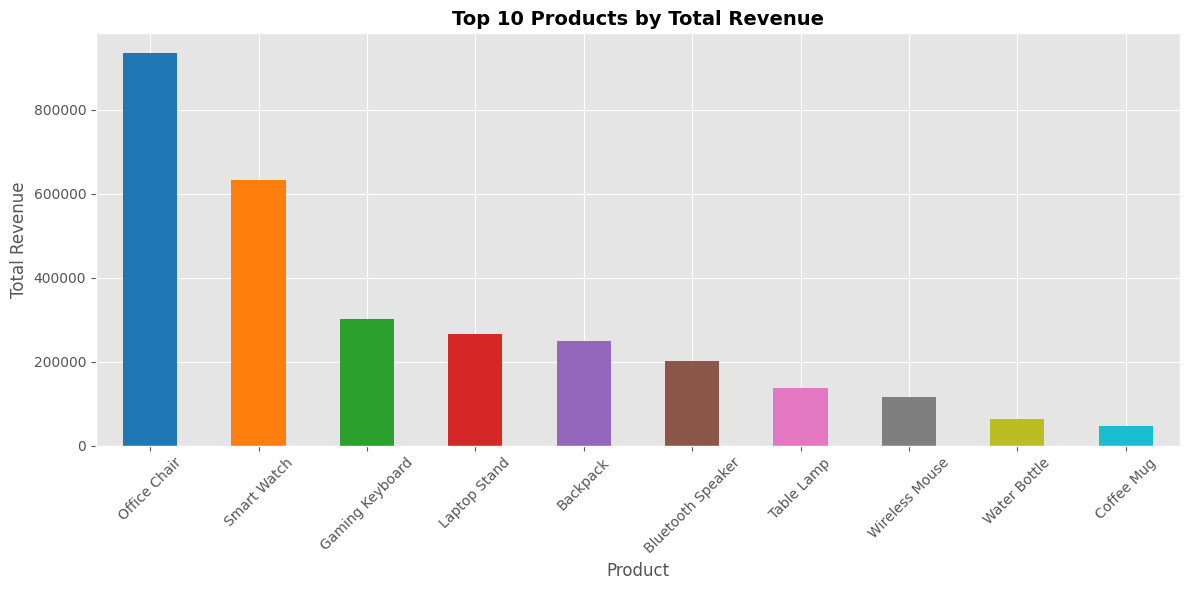

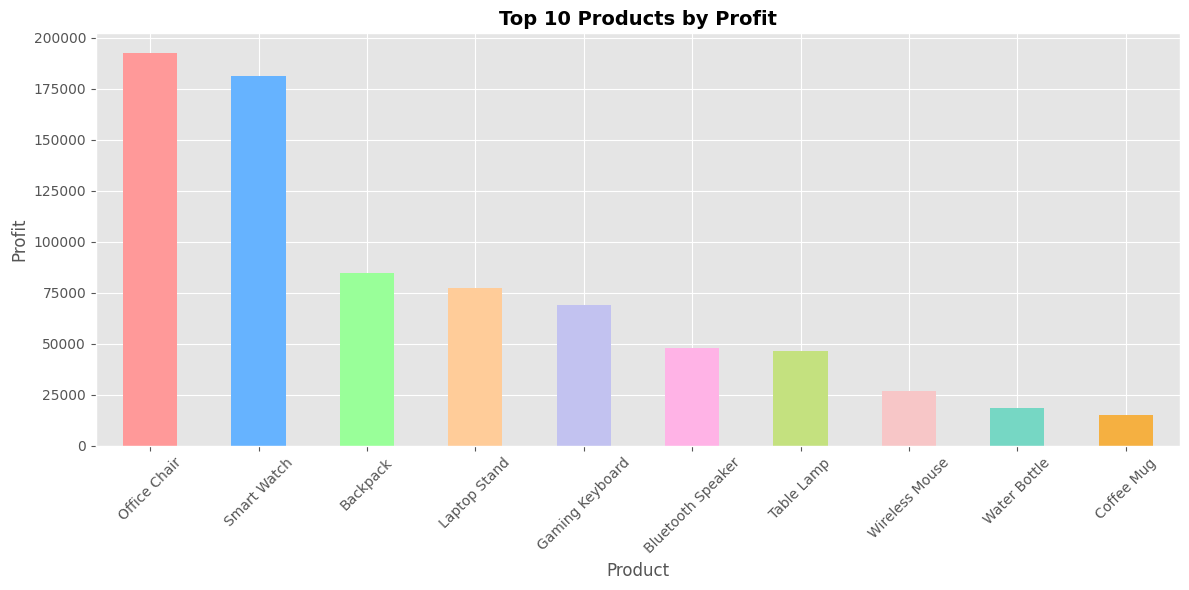

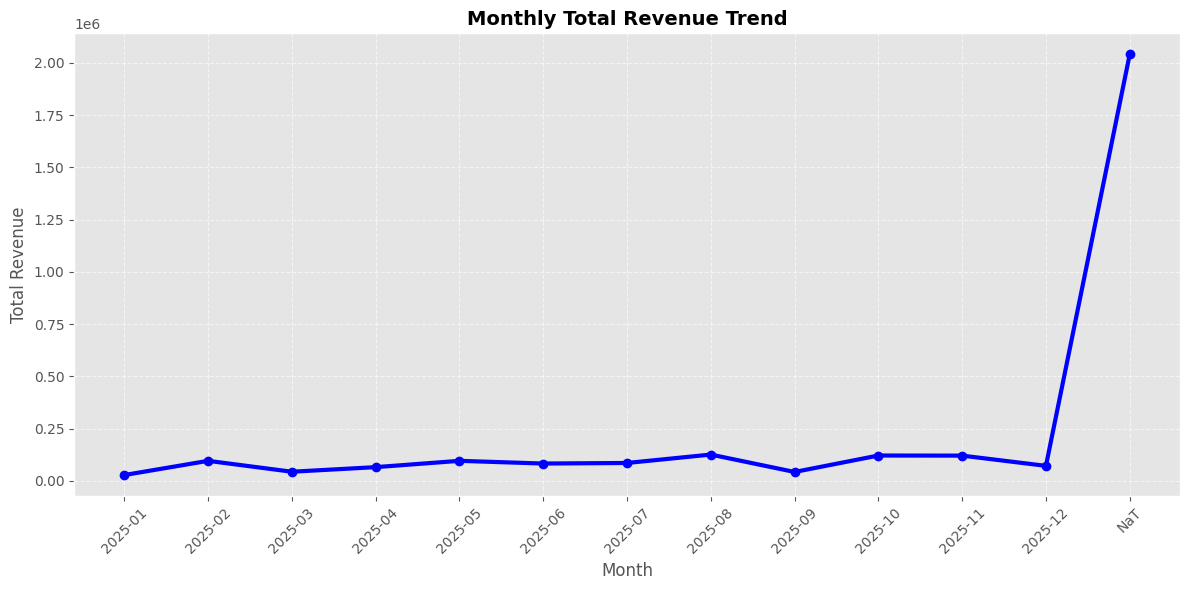

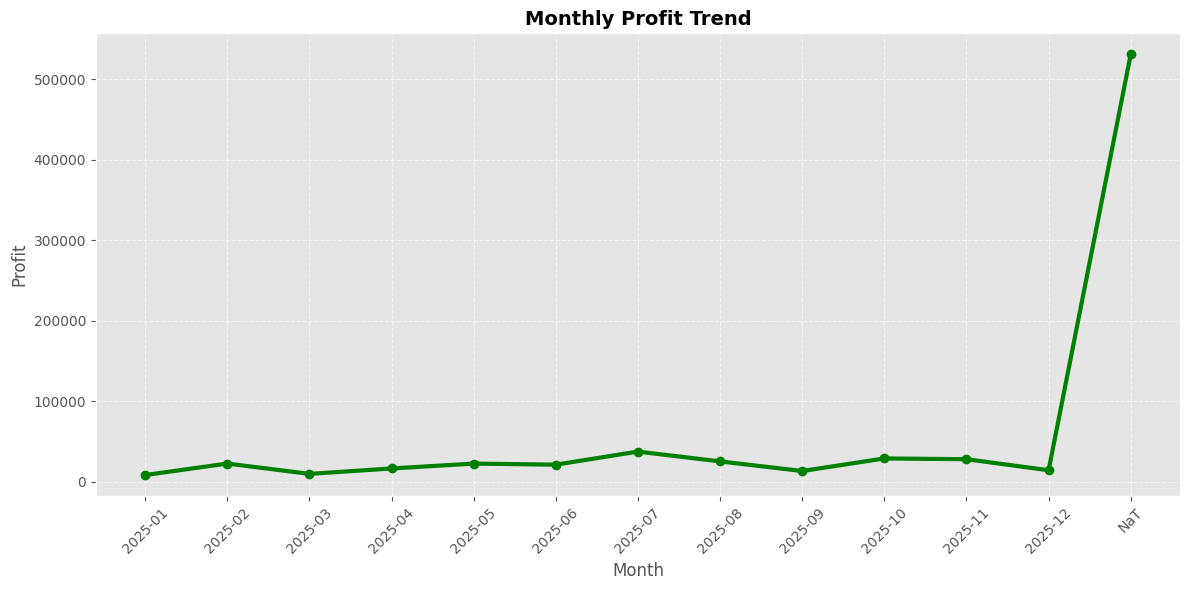

In [ ]:
# ============================================
# DASHBOARD VISUALIZATIONS
# ============================================

import matplotlib.pyplot as plt

# -----------------------------
# 1. Top 10 Products by Revenue
# -----------------------------
top_10_revenue = clean_df.groupby("Product")["Total_Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_10_revenue.plot(kind="bar", color=["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
                                       "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"])
plt.title("Top 10 Products by Total Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Top 10 Products by Profit
# -----------------------------
top_10_profit = clean_df.groupby("Product")["Profit"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_10_profit.plot(kind="bar", color=["#ff9999","#66b3ff","#99ff99","#ffcc99","#c2c2f0",
                                      "#ffb3e6","#c4e17f","#f7c6c7","#76d7c4","#f5b041"])
plt.title("Top 10 Products by Profit", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. Monthly Revenue Trend
# -----------------------------
monthly_revenue = clean_df.groupby("Month")["Total_Revenue"].sum().sort_index()

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index, monthly_revenue.values,
         marker="o", linewidth=3, color="blue")
plt.title("Monthly Total Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Monthly Profit Trend
# -----------------------------
monthly_profit = clean_df.groupby("Month")["Profit"].sum().sort_index()

plt.figure(figsize=(12,6))
plt.plot(monthly_profit.index, monthly_profit.values,
         marker="o", linewidth=3, color="green")
plt.title("Monthly Profit Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()